<a href="https://colab.research.google.com/github/areejakram24/MY_ProjectsandLabs/blob/main/M4L1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Module 4: Perceptron and Gradient Descent
## Lab 1: Perceptron

In this lab, we will be studying the perceptron learning algorithm.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

First we need to define a labeled data set. Let's make a toy dataset.

In [ ]:
X = np.array([
    [-2, 4],
    [4, 1],
    [1, 6],
    [2, 4],
    [6, 2]
])

Next we need to add a bias term -1 into the data set.

In [ ]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [ ]:
y = np.array([-1, -1, 1, 1, 1])

This small toy data set contains two samples labeled with −1 and three samples labeled with +1. This means we have a binary classification problem, as the data set contains two sample classes. Lets plot the dataset to see, that is is linearly seperable

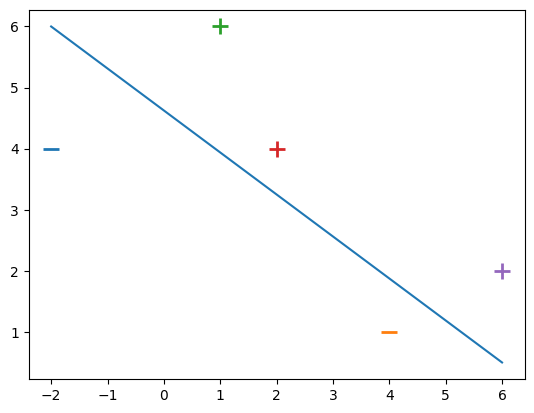

In [ ]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Print a possible hyperplane, that is seperating the two classes.
plt.plot([-2, 6], [6, 0.5])

Finally we can code our Perceptron algorithm using our update rule. To keep it simple, we will linearly loop over the sample set. For larger data sets it makes sence, to randomly pick a sample during each iteration in the for-loop.

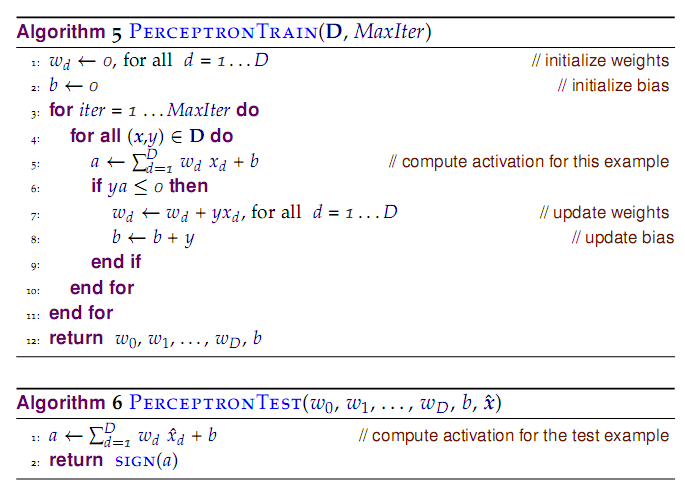

The algorithm is shown in the above image.

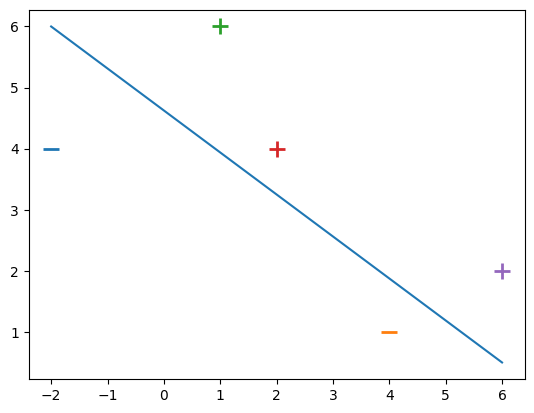

In [ ]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Print a possible hyperplane, that is seperating the two classes.
plt.plot([-2, 6], [6, 0.5])

In [ ]:
def perceptron_algo_plot(X, Y):
    '''
    train perceptron and plot the total loss in each epoch.

    :param X: data samples
    :param Y: data labels
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    eta = 1
    n = 30
    errors = []

    for t in range(n):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)

    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')

    return w

Next, we will see the the training error at each epoch.

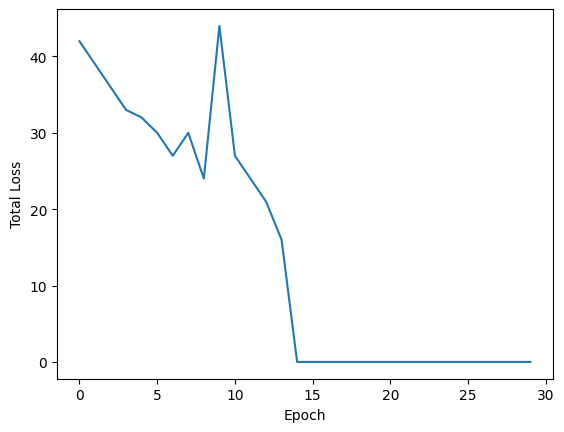

In [ ]:
w = perceptron_algo_plot(X, y)

We now plot the decision boundary and check which samples have been classified as positive and which samples have been classified as negative.

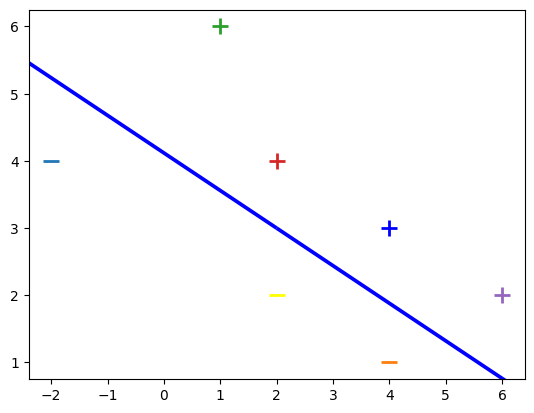

In [ ]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Add our test samples

plt.scatter(2, 2, s=120, marker='_', linewidths=2, color='yellow')
plt.scatter(4, 3, s=120, marker='+', linewidths=2, color='blue')

# Print the hyperplane calculated by perceptron_sgd()
x2 = [w[0], w[1], -w[1], w[0]]
x3 = [w[0], w[1], w[1], -w[0]]

x2x3 = np.array([x2, x3])
X, Y, U, V = zip(*x2x3)
ax = plt.gca()
ax.quiver(X, Y, U, V, scale=1, color='blue')

As you can see, our algorithm has correctly classified all the samples. The decision boundary is shown in blue.

# Things to try


1.   Try this on a real dataset like the Sonar dataset or the Banknote Dataset and show the error plot.
2.   Increase/decrease the learning rate to see how many iterations will be take to coverge. Does it even converge on a huge learning rate?
4. Take a toy dataset that is not linearly separable and run the perceptron algorithm on it. What happens? Note your observations. An example is given below.



Sonar Dataset

---



In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv('sonar.csv.xls')

df.rename(columns={df.columns[-1]: 'target'}, inplace=True)

Saving sonar.csv.xls to sonar.csv (2).xls


In [ ]:
import plotly.express as px

colors = ['#FFB6C1', '#DA70D6']
fig = px.pie(df,names='target',title='Rocks vs Mines',color_discrete_sequence=colors,
             hole=0)

fig.update_traces(pull=[0.05, 0.05])

fig.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Map target labels: R -> -1, M -> +1
df['target'] = df['target'].map({'R': -1, 'M': 1})

# Features and labels
X = df.drop(columns=['target']).values
y = df['target'].values

# Train-test split
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)


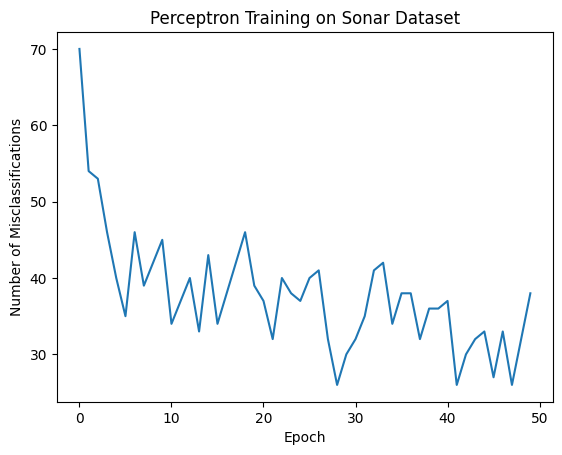

In [ ]:
def perceptron_algo_plot(X, Y, eta=0.1, n_epochs=50):
    """
    Train perceptron and plot the number of misclassifications in each epoch.
    """
    # Add bias term by appending a column of ones
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.zeros(X.shape[1])
    errors = []

    for epoch in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(x, w) * Y[i]) <= 0:
                total_error += 1
                w = w + eta * x * Y[i]
        errors.append(total_error)

    # Plot training errors
    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Number of Misclassifications')
    plt.title('Perceptron Training on Sonar Dataset')
    plt.show()

    return w

# Train perceptron
w = perceptron_algo_plot(train_x, train_y, eta=0.1, n_epochs=50)


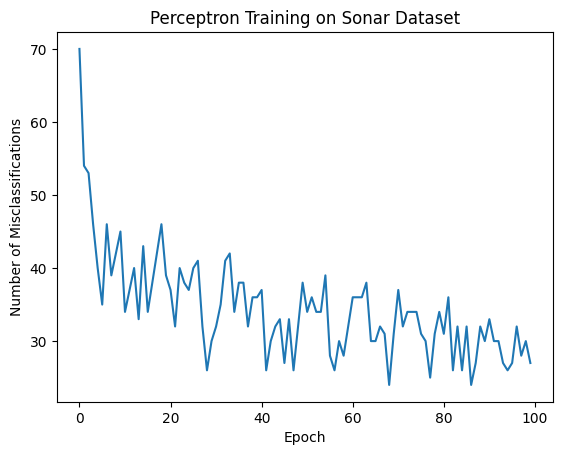

In [ ]:
def perceptron_algo_plot(X, Y, eta=0.01, n_epochs=100):
    """
    Train perceptron and plot the number of misclassifications in each epoch.
    """
    # Add bias term by appending a column of ones
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.zeros(X.shape[1])
    errors = []

    for epoch in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(x, w) * Y[i]) <= 0:
                total_error += 1
                w = w + eta * x * Y[i]
        errors.append(total_error)

    # Plot training errors
    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Number of Misclassifications')
    plt.title('Perceptron Training on Sonar Dataset')
    plt.show()

    return w

# Train perceptron
w = perceptron_algo_plot(train_x, train_y, eta=0.01, n_epochs=100)

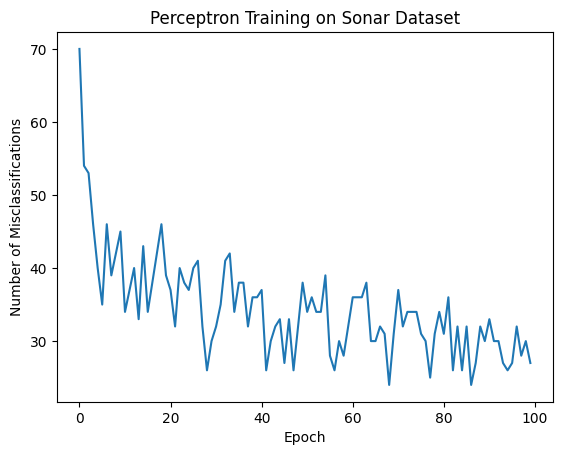

In [ ]:
def perceptron_algo_plot(X, Y, eta=1, n_epochs=100):
    """
    Train perceptron and plot the number of misclassifications in each epoch.
    """
    # Add bias term by appending a column of ones
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.zeros(X.shape[1])
    errors = []

    for epoch in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(x, w) * Y[i]) <= 0:
                total_error += 1
                w = w + eta * x * Y[i]
        errors.append(total_error)

    # Plot training errors
    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Number of Misclassifications')
    plt.title('Perceptron Training on Sonar Dataset')
    plt.show()

    return w

# Train perceptron
w = perceptron_algo_plot(train_x, train_y, eta=1, n_epochs=100)

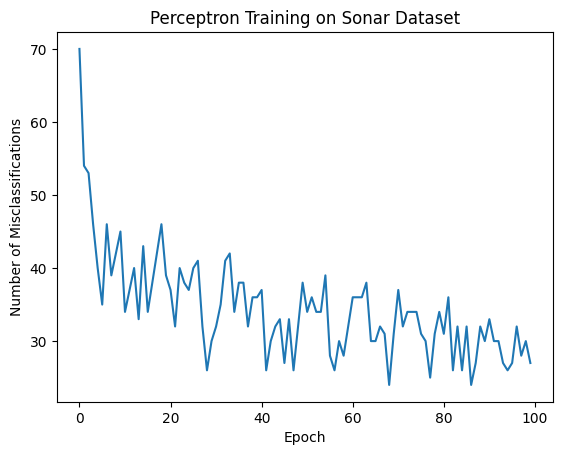

In [ ]:
def perceptron_algo_plot(X, Y, eta=5, n_epochs=100):
    """
    Train perceptron and plot the number of misclassifications in each epoch.
    """
    # Add bias term by appending a column of ones
    X = np.insert(X, 0, 1, axis=1)

    # Initialize weights
    w = np.zeros(X.shape[1])
    errors = []

    for epoch in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(x, w) * Y[i]) <= 0:
                total_error += 1
                w = w + eta * x * Y[i]
        errors.append(total_error)

    # Plot training errors
    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Number of Misclassifications')
    plt.title('Perceptron Training on Sonar Dataset')
    plt.show()

    return w

# Train perceptron
w = perceptron_algo_plot(train_x, train_y, eta=5, n_epochs=100)

We don't see any convergence.

In [ ]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [ ]:
y = np.array([-1, -1, 1, -1, -1])

[-2.  3. 15.]


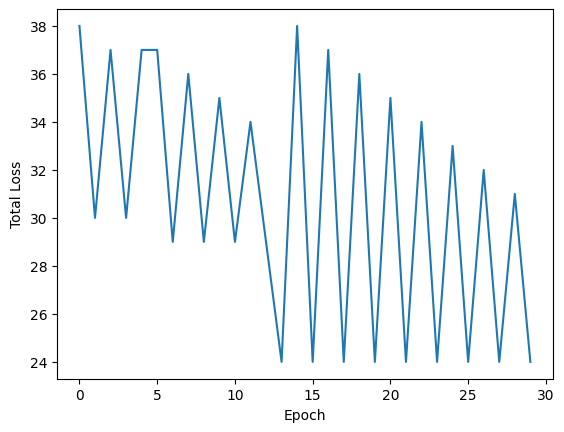

In [ ]:
print(perceptron_algo_plot(X, y))

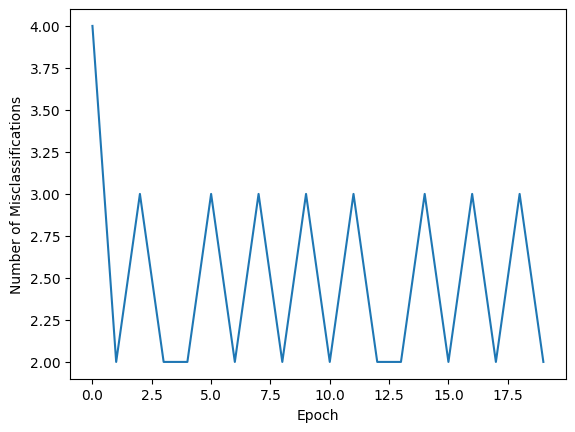

In [ ]:
#toy dataset
import numpy as np
import matplotlib.pyplot as plt

# Toy dataset (not linearly separable)
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])
y = np.array([-1, -1, 1, -1, -1])  # labels

def perceptron(X, y, eta=1, n_epochs=20):
    w = np.zeros(X.shape[1])
    errors = []

    for epoch in range(n_epochs):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(x, w) * y[i]) <= 0:
                total_error += 1
                w = w + eta * x * y[i]
        errors.append(total_error)

    return w, errors

# Train perceptron
w, errors = perceptron(X, y, eta=1, n_epochs=20)

plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")

plt.show()


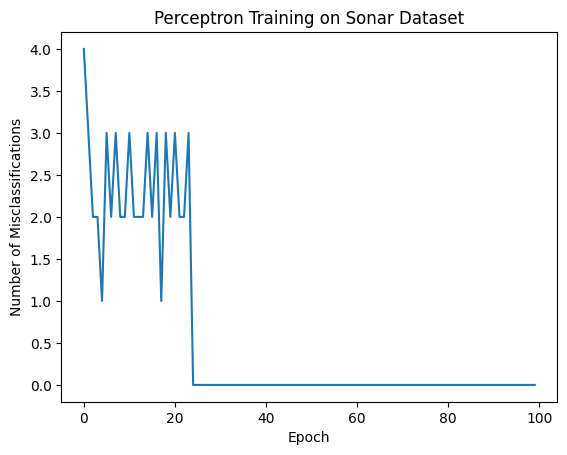

[ 105.   -5.   35. -105.]


In [ ]:
# Toy dataset (not linearly separable)
X = np.array([
    [2, 9, -1],
    [-3, -1, -1],
    [6, -6, -1],
    [8, -4, -1],
    [-6, -2, -1],
])
y = np.array([1, 1, -1, 1, 1])

print(perceptron_algo_plot(X, y))

 If the training data is not Linearly Separable, the perceptron algorithm will eventually repeat the same set of weights and thereby enter an infinite loop.

## **Additional Critical Thinking Questions**

1. Consider the following dataset where x = (x1, x2) ∈ {0, 1}× {0, 1}, y ∈ {−, +}. Note that this dataset is corresponding to the boolean function “AND” over the 2-bit binary input.

  Suppose we are training a Perceptron to learn on this dataset and we initialize w0 = 0 and b0 = 0.

  Please i) answer if this dataset is learnable by Perceptron, and ii) if so, write down the weights update procedure for each iteration; if not, explain why.


2. Extending AND to any boolean functions over a 2-bit binary input, where we have (2^2)^2 = 16 possible distinct boolean functions in total, among which how many of them can be learnable by a Perceptron?

  Please also write down the truth table(s) of the boolean functions that are not learnable, if there are any.

1. AND function on x1 and x2 would give rise to the following turth table:
```
x1 x2 y
0  0  -1
0  1  -1
1  0  -1
1  1  +1
```
This would turn out to be a linearly separable graph . Yes, the perceptron would learn this dataset.
```
Initial weights would be (0,0) and b0=0
we know that activation a = wx+b
for the above table (0,0) a=0
[0(0)+0(0)+0=0]
update w1=(0,0)-1(0,0)=-1

for (0,1) a=-1
[0(0)+0(1)+(−1)=−1]
w2=(0,0)b =−1
same for w3.

for (1,1) y=1.
0(1)+0(1)+(−1)=−1
so, w4=(0,0)+1(1,1)=−1+1=0
```
similary w5 and w6 get updated to -1 and then -2 respectively.
The whole process repeats and after 8th step updation stops.

2. Out of all 16 2-bit functions perceptron doesnt learn for xor and xnor.
They are not lineslry separable.
```
x1 x2 y
0  0  -1
0  1  +1
1  0  +1
1  1  -1
```
```
x1 x2 y
0  0  +1
0  1  -1
1  0  -1
1  1  +1
```
